# PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EDA)
## Bộ dữ liệu thời tiết Việt Nam cho dự báo mưa
Sổ tay này phân tích bộ dữ liệu Thời tiết Việt Nam để khám phá phân phối đặc trưng, giá trị thiếu, độ tương quan với lượng mưa và phát hiện ngoại lệ.

### 1. Thiết lập môi trường và thư viện

In [1]:
import os
import glob
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

figures_dir = os.path.join("..", "outputs", "figures")
os.makedirs(figures_dir, exist_ok=True)

### 2. Tải và tổng quan bộ dữ liệu

In [2]:
data_dir = os.path.join("..", "data", "raw")
files = sorted(glob.glob(os.path.join(data_dir, "weather-vn-*.csv")))
df = pd.read_csv(files[0])
print("Kích thước:", df.shape)
print("Kiểu dữ liệu:\n", df.dtypes)
df.head()

Kích thước: (420546, 20)
Kiểu dữ liệu:
 time                       str
province                   str
city                       str
temperature            float64
temp_min               float64
temp_max               float64
humidity               float64
feels_like             float64
visibility             float64
precipitation          float64
cloudcover             float64
wind_speed             float64
wind_gust              float64
wind_direction         float64
pressure               float64
is_day                   int64
weather_code             int64
weather_main               str
weather_description        str
weather_icon               str
dtype: object


,time,province,city,temperature,temp_min,temp_max,humidity,feels_like,visibility,precipitation,cloudcover,wind_speed,wind_gust,wind_direction,pressure,is_day,weather_code,weather_main,weather_description,weather_icon
0,2025-06-29 23:29:22,An Giang-Chau Doc,Chau Doc,25.63,25.63,25.63,79.0,26.31,10000.0,0.0,100.0,2.36,4.58,277.0,1008.0,0,804,Clouds,overcast clouds,04n
1,2025-06-29 23:30:30,An Giang-Chau Doc,Chau Doc,25.63,25.63,25.63,79.0,26.31,10000.0,0.0,100.0,2.36,4.58,277.0,1008.0,0,804,Clouds,overcast clouds,04n
2,2025-06-29 23:32:58,An Giang-Chau Doc,Chau Doc,25.48,25.48,25.48,78.0,26.12,10000.0,0.0,100.0,2.24,4.24,262.0,1007.0,0,804,Clouds,overcast clouds,04n
3,2025-06-29 23:35:01,An Giang-Chau Doc,Chau Doc,25.48,25.48,25.48,78.0,26.12,10000.0,0.0,100.0,2.24,4.24,262.0,1007.0,0,804,Clouds,overcast clouds,04n
4,2025-06-29 23:37:03,An Giang-Chau Doc,Chau Doc,25.48,25.48,25.48,78.0,26.12,10000.0,0.0,100.0,2.24,4.24,262.0,1007.0,0,804,Clouds,overcast clouds,04n


### 3. Phân tích giá trị thiếu

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Số lượng thiếu': missing, 'Tỷ lệ (%)': missing_pct})
print(missing_df[missing_df['Số lượng thiếu'] > 0])

            Số lượng thiếu  Tỷ lệ (%)
visibility             878   0.208776


### 4. Phân tích dòng trùng lặp

In [4]:
num_dup = df.duplicated().sum()
print(f"Số lượng dòng trùng lặp: {num_dup}")

Số lượng dòng trùng lặp: 468


### 5. Tóm tắt thống kê

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature,420546.0,27.919003,3.181019,18.26,25.85,27.54,30.05,38.03
temp_min,420546.0,27.894025,3.175739,18.26,25.83,27.51,30.03,38.03
temp_max,420546.0,27.931143,3.186250,18.26,25.86,27.55,30.07,38.03
humidity,420546.0,79.809063,12.965949,37.00,71.00,82.00,90.00,100.00
feels_like,420546.0,31.206896,5.243260,18.73,26.32,31.19,35.70,45.01
visibility,419668.0,9782.145000,1078.752358,15.00,10000.00,10000.00,10000.00,10000.00
precipitation,420546.0,0.217634,0.983775,0.00,0.00,0.00,0.00,37.59
cloudcover,420546.0,79.775038,29.801688,0.00,68.00,98.00,100.00,100.00
wind_speed,420546.0,2.663633,1.795322,0.00,1.27,2.24,3.68,10.29
wind_gust,420546.0,3.854220,3.302735,0.00,1.05,2.84,6.48,14.90


### 6. Ma trận tương quan đặc trưng

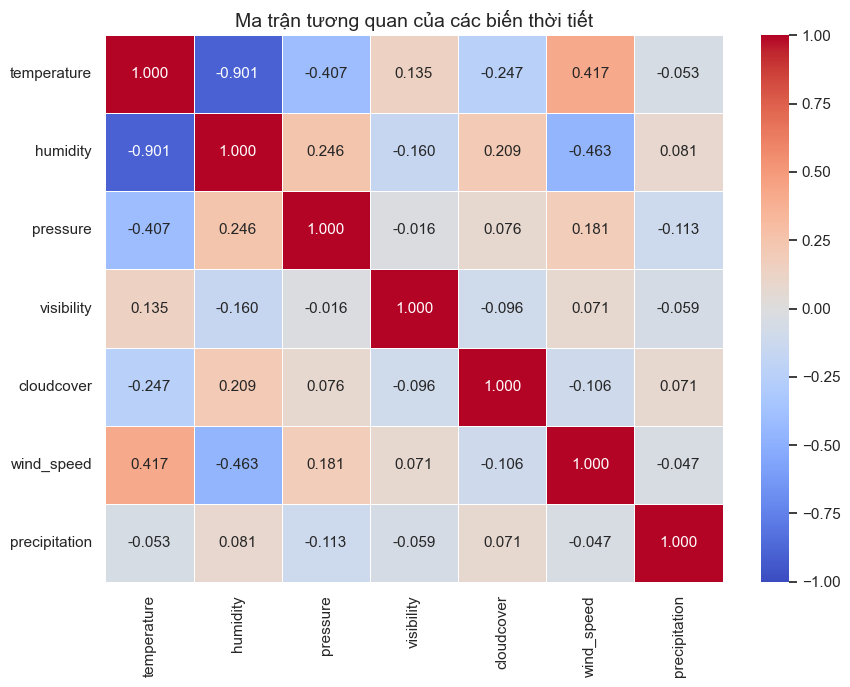

In [6]:
num_cols = ["temperature", "humidity", "pressure", "visibility", "cloudcover", "wind_speed", "precipitation"]
num_cols = [c for c in num_cols if c in df.columns]
corr = df[num_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".3f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Ma trận tương quan của các biến thời tiết")
plt.tight_layout()
plt.show()

### 7. Phân phối đặc trưng

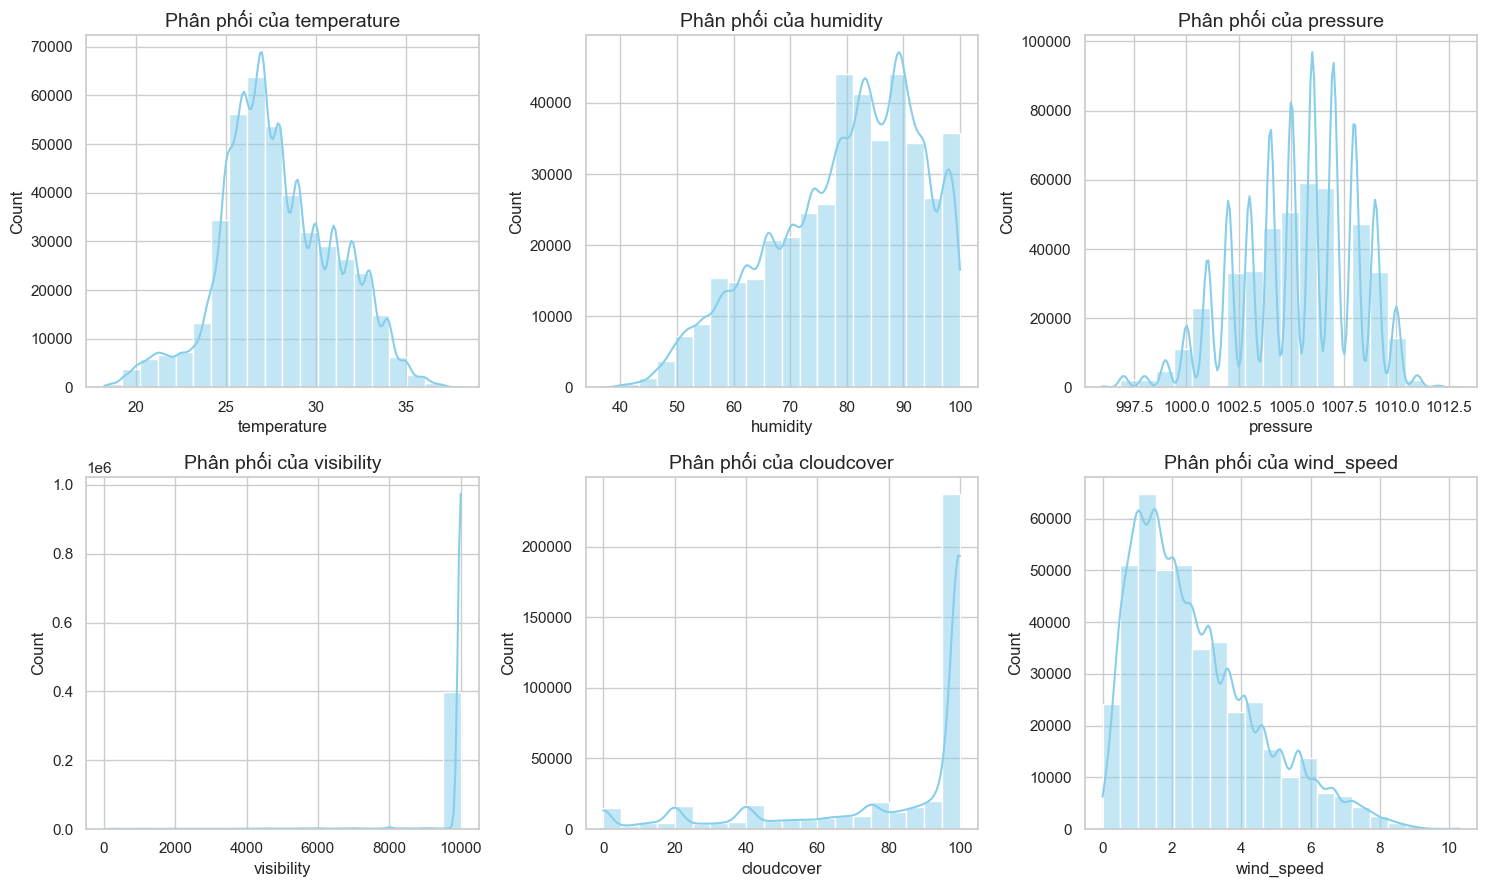

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for idx, col in enumerate(num_cols[:6]):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[idx], color="skyblue", bins=20)
    axes[idx].set_title(f"Phân phối của {col}")
plt.tight_layout()
plt.show()

### 8. Phát hiện ngoại lệ (Biểu đồ hộp)

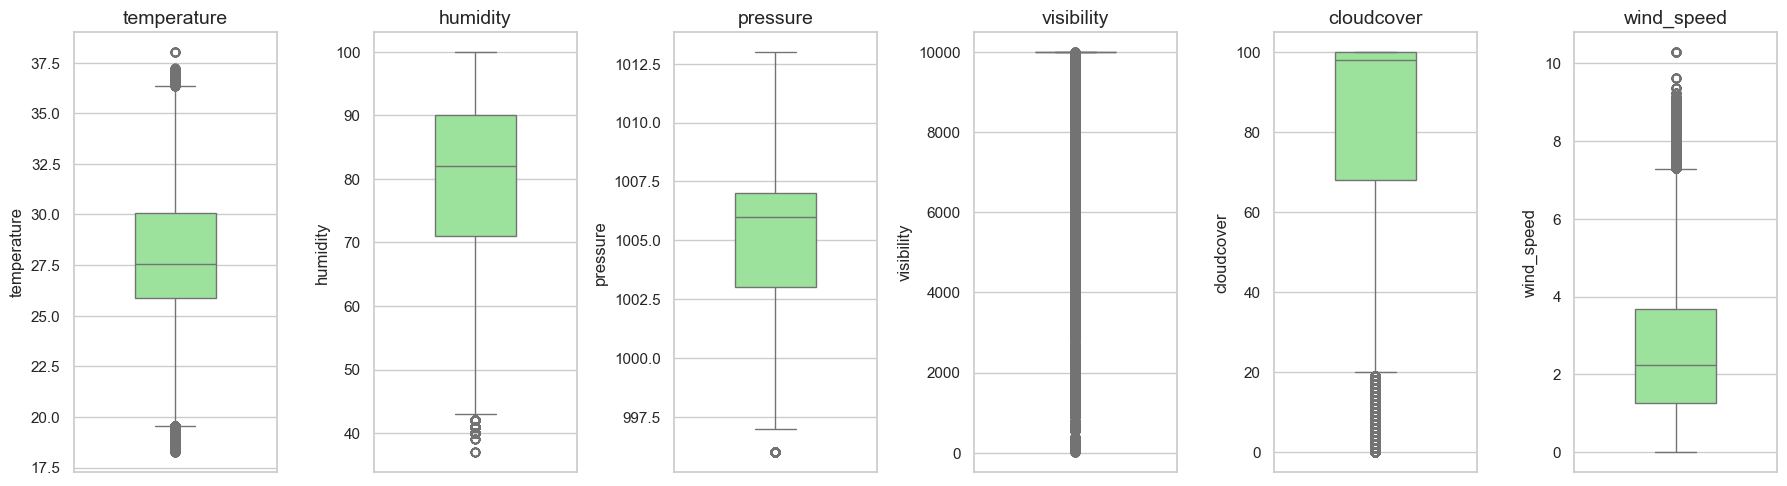

In [8]:
fig, axes = plt.subplots(1, 6, figsize=(18, 5))
for idx, col in enumerate(num_cols[:6]):
    sns.boxplot(y=df[col].dropna(), ax=axes[idx], color="lightgreen", width=0.4)
    axes[idx].set_title(col)
plt.tight_layout()
plt.show()